In [1]:
import pandas as pd

# Load data
data = pd.read_csv("ev_charging_patterns.csv")

In [2]:
# Create datetime column
data['datetime'] = pd.to_datetime(data['Charging Start Time'])

In [3]:
# Create demand column
data['demand'] = data['Energy Consumed (kWh)']

In [4]:
# Now select columns (this will work now)
data = data[['datetime', 'demand', 'Temperature (°C)']]

In [5]:
# Aggregate
data = data.groupby('datetime').agg({
    'demand': 'sum',
    'Temperature (°C)': 'mean'
}).reset_index()

In [6]:
# Sort
data = data.sort_values('datetime')

In [7]:
from prophet import Prophet

In [8]:
df = data[['datetime', 'demand']]
df.columns = ['ds', 'y']

In [9]:
model = Prophet()
model.fit(df)

20:08:06 - cmdstanpy - INFO - Chain [1] start processing
20:08:06 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(periods=24)
forecast = model.predict(future)

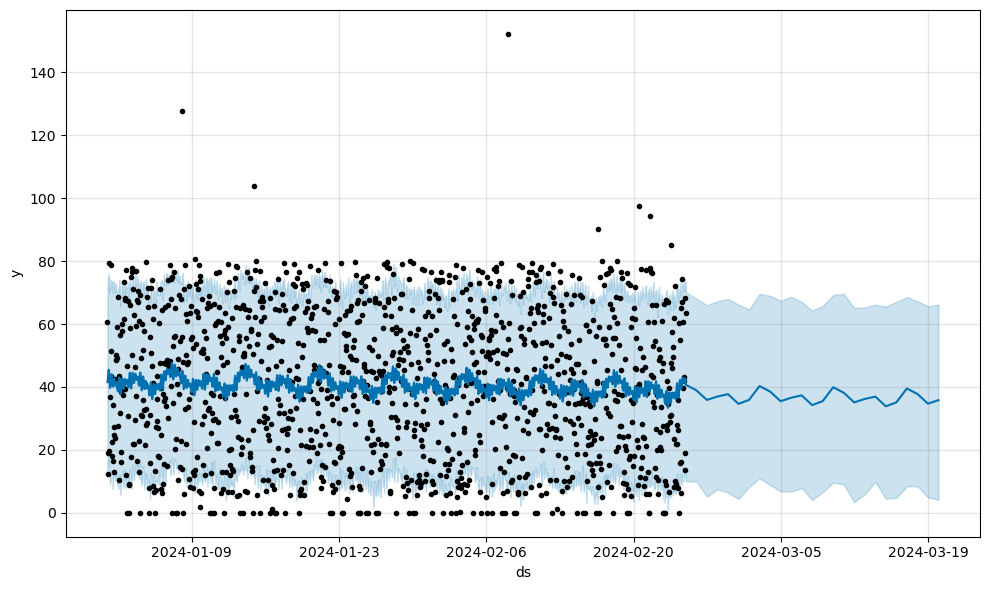

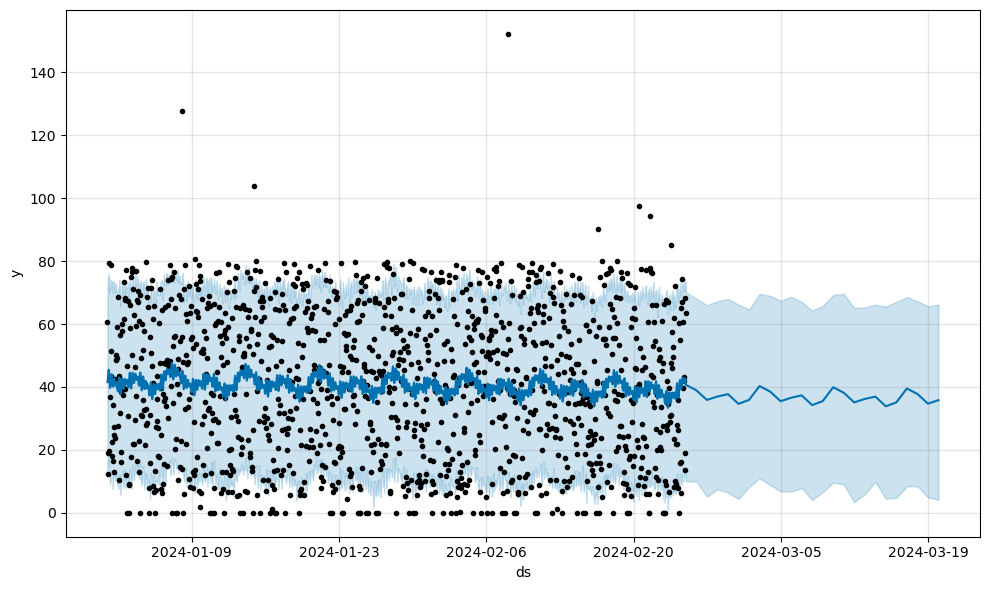

In [11]:
model.plot(forecast)

In [ ]:
data.to_csv("final_ev_data.csv",index=